# 01 · 数据分析（EDA）—— 手把手

> 这份 notebook 是我们**一起一步步写**的：每一节先说「做什么 + 为什么」，再给代码。
> 目标不是一次做完，而是**每一步都看懂**。

---

## EDA 要回答的 6 个问题

| # | 问题 | 为什么重要 |
|---|------|-----------|
| 1 | 数据长什么样？（行数 / 列数 / 类型） | 先知道"盘子多大"、哪些是数字哪些是文字 |
| 2 | 目标 `SalePrice` 长什么样？ | 决定要不要做 `log` 变换 —— 这直接影响最终分数 |
| 3 | 哪些列有缺失？缺失**代表什么含义**？ | 填错方向会毁掉信息 |
| 4 | 每个特征单独看是什么分布？ | 找出该变换的列、该合并的高基数列 |
| 5 | 每个特征和房价有什么关系？ | 找强特征、找异常样本 |
| 6 | 训练集和测试集是否"同源"？ | 防止本地 CV 很好、提交却崩 |

> ⚠️ 纪律：`data/raw/` 只读，**绝不**在这里修改原始文件。

---

## Step 1 · 加载数据 + 全局概览

**做什么**：把两个 csv 读进来，看行数、列数、每列的类型。

**为什么**：这是所有分析的起点 —— 先知道"盘子多大"，以及哪些列是**数字**、哪些是**文字**。
因为这两类特征的后续处理方式**完全不同**（数字可以算均值/相关性，文字不行，得先编码）。

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---- 1) 定位项目根目录（无论 notebook 从哪运行，都能找到 data/）----
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("项目根目录:", ROOT)

# ---- 2) 读入原始数据（data/raw 只读，绝不在这里修改它）----
train = pd.read_csv(ROOT / "data" / "raw" / "train.csv")
test = pd.read_csv(ROOT / "data" / "raw" / "test.csv")

# ---- 3) 最基本的"体型"：行数 × 列数 ----
print("train:", train.shape, "| test:", test.shape)

# ---- 4) 每一列是什么类型？----
# 注意：pandas 3.0 起，文字列的 dtype 显示为 `str`（不再是老的 `object`）
#       int64 / float64 = 数字；str = 文字
train.dtypes.value_counts()

项目根目录: c:\Users\23353\Desktop\house-prices-kaggle
train: (1460, 81) | test: (1459, 80)


str        43
int64      35
float64     3
Name: count, dtype: int64

### 🔍 运行完请观察这几个数

- `train.shape` 应为 `(1460, 81)`：1460 行 × 81 列。81 = **79 个特征** + `Id` + `SalePrice`。
- `test.shape` 应为 `(1459, 80)`：80 列 —— **少的那一列正是 `SalePrice`**。
- `dtypes.value_counts()` 告诉你：**数字列多少个、文字列多少个**。
  ⚠️ pandas 3.0 起，文字列 dtype 显示为 **`str`**（不再是老的 `object`）——
  所以你会看到 `str: 43, int64: 35, float64: 3`。

**思考题（先自己猜，先别急着往下）**

1. 为什么 test 比 train 少一列？少的为什么偏偏是它？
2. `Id` 这一列，算"特征"吗？训练模型时该不该把它喂进去？
3. `MSSubClass` 的类型是 `int64`（数字），但它是"真正的数字"吗？

---

## Step 2 · 绘图环境准备

**做什么**：设置 matplotlib / seaborn 的主题、字体、画布分辨率。

**为什么**：后面要画一堆分布图和散点图。提前统一好"画图环境"（尤其是**中文显示**，
否则图里的中文会变成一个个方框），后面就不用每张图重复配置。

In [15]:
# —— Step 2 · 绘图环境准备 ——
# 数据已经在 Step 1 读进来了（train / test / ROOT），这里只准备"画图"的环境。
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
# 让 matplotlib 正常显示中文（Windows 自带字体）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## L1 · 全局概览

先搞清楚：多少行、多少列、哪些是数值、哪些是类别、占多少内存。

In [16]:
num_cols = train.select_dtypes(include="number").columns.tolist()
cat_cols = train.select_dtypes(exclude="number").columns.tolist()
print(f"数值列 {len(num_cols)} 个 | 类别列 {len(cat_cols)} 个")
print(f"内存占用: {train.memory_usage(deep=True).sum()/1024**2:.2f} MB")

overview = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(),
    "n_missing": train.isna().sum(),
    "missing_pct": (train.isna().mean() * 100).round(1),
})
overview.head(15)

数值列 38 个 | 类别列 43 个
内存占用: 3.43 MB


,dtype,n_unique,n_missing,missing_pct
Id,int64,1460,0,0.0
MSSubClass,int64,15,0,0.0
MSZoning,str,5,0,0.0
LotFrontage,float64,110,259,17.7
LotArea,int64,1073,0,0.0
Street,str,2,0,0.0
Alley,str,2,1369,93.8
LotShape,str,4,0,0.0
LandContour,str,4,0,0.0
Utilities,str,2,0,0.0


## L2 · 目标变量 SalePrice

看分布形态和偏度，决定**要不要对目标做 log 变换**（官方指标就是 RMSE-log）。

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

偏度 skew = 1.88  (>0 表示右偏)


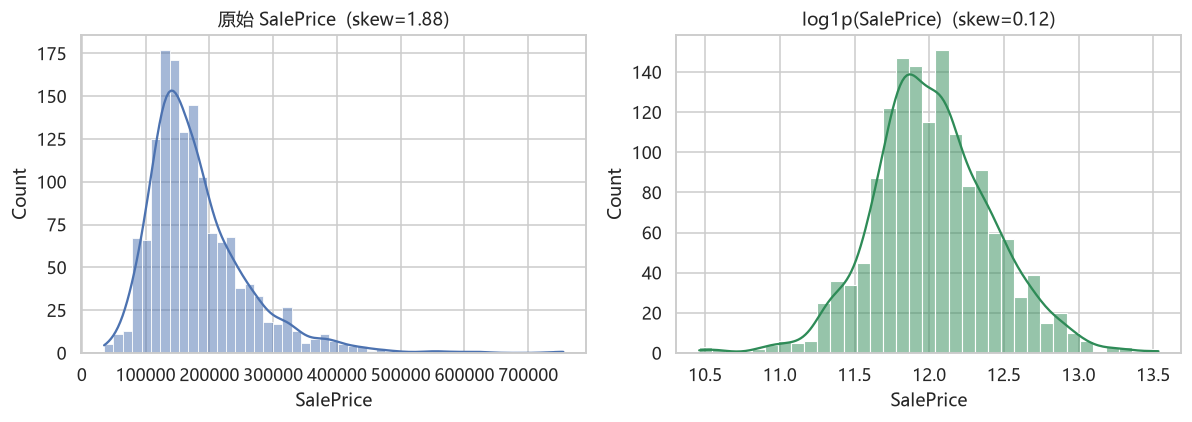

In [17]:
print(train["SalePrice"].describe().round(0))
print(f"\n偏度 skew = {train['SalePrice'].skew():.2f}  (>0 表示右偏)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title(f"原始 SalePrice  (skew={train['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(SalePrice)  (skew={np.log1p(train['SalePrice']).skew():.2f})")
plt.tight_layout()
plt.show()

## L3.1 · 缺失值：区分"真缺失"和"无该设施"

这是本项目**最大的坑**：很多 `NA` 不是数据丢了，而是"没有这个东西"。

判断标准：看数据字典里该字段**是否显式列出了 `NA` 这个取值**。

> ⚠️ 隐藏陷阱一：**语义缺失要按列的类型分开填**。
> - 分类列（如 `PoolQC`）→ 填 `"None"`
> - 数值列（如 `GarageYrBlt`）→ 填 `0`，**不能填中位数**
>
> 给"没有车库"的房子填上中位数车库年份，等于凭空捏造了一条信息。

> ⚠️ 隐藏陷阱二：**`MasVnrType` 是"混合缺失"，不能一刀切**（872 行缺失，但含义不同）：
> - **859 行**：`MasVnrArea = 0` → 确实无饰面 → 填 `"None"` ✅
> - **5 行**：`MasVnrArea > 0` → **其实有饰面**，`MasVnrType` 才是真缺失 → 应单独填补（如众数 `BrkFace`）
> - **8 行**：两列同时缺失 → 无法判断，按字典默认当"无饰面"处理
>
> 数量虽少（13/1460），但"无脑填 `None`"会把这 5 行标错。**知道这个坑，比急着修它更重要。**

In [26]:
# 语义缺失要分两种填充方式：分类列填 "None"，数值列填 0
NA_MEANS_NONE = {                      # 分类列：没有该设施 → 填 "None"
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",   # ⚠️ 混合情况：859 行确实无饰面；另有 5 行其实有饰面(面积>0)是真缺失
}
# 数值列：没有该设施 → 填 0（注意：不能填中位数！）
#   GarageYrBlt 缺失 81：与 GarageType 缺失完全对应（已核验），= 没有车库 → 填 0
#   MasVnrArea  缺失  8：这 8 行的 MasVnrType 也缺，按字典当"无饰面" → 填 0
NA_MEANS_ZERO = {"GarageYrBlt", "MasVnrArea"}
# 剩下的 LotFrontage / Electrical 才是真缺失，要用统计量填补

miss = train.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
tbl = pd.DataFrame({"n_missing": miss, "pct": (miss / len(train) * 100).round(1)})


def _label(col: str) -> str:
    if col in NA_MEANS_NONE:
        return "无该设施(分类→None)"
    if col in NA_MEANS_ZERO:
        return "无该设施(数值→0)"
    return "真缺失(需统计填补)"


tbl["NA的含义"] = [_label(c) for c in tbl.index]
n_semantic = int(tbl["NA的含义"].str.startswith("无该设施").sum())
n_real = int(tbl["NA的含义"].str.startswith("真缺失").sum())
print(f"共 {len(tbl)} 列存在缺失；总缺失格子数 {int(miss.sum())}")
print(f"  其中语义缺失(无该设施) {n_semantic} 列 | 真缺失 {n_real} 列")
tbl

共 19 列存在缺失；总缺失格子数 7829
  其中语义缺失(无该设施) 17 列 | 真缺失 2 列


,n_missing,pct,NA的含义
PoolQC,1453,99.5,无该设施(分类→None)
MiscFeature,1406,96.3,无该设施(分类→None)
Alley,1369,93.8,无该设施(分类→None)
Fence,1179,80.8,无该设施(分类→None)
MasVnrType,872,59.7,无该设施(分类→None)
FireplaceQu,690,47.3,无该设施(分类→None)
LotFrontage,259,17.7,真缺失(需统计填补)
GarageType,81,5.5,无该设施(分类→None)
GarageYrBlt,81,5.5,无该设施(数值→0)
GarageFinish,81,5.5,无该设施(分类→None)


## L3.2 · 数值特征：偏态排行

右偏严重的特征，线性模型吃不消，通常要做 log / Box-Cox 变换。

> 💡 但**不要无脑全变换**：`MiscVal`(24.5)、`PoolArea`(14.8) 这类偏度极大的列，
> 是因为 **绝大多数值是 0**（几乎没有房子有泳池/杂项设施），
> 本质上是"稀疏的 0/非 0"，log 变换救不了 —— 更好的做法是转成 `HasPool` 这类布尔标志。

In [19]:
skew_num = train[num_cols].skew().sort_values(ascending=False)
print("偏度最高的 12 个特征（右偏严重）：")
print(skew_num.head(12).round(2))

偏度最高的 12 个特征（右偏严重）：
MiscVal          24.48
PoolArea         14.83
LotArea          12.21
3SsnPorch        10.30
LowQualFinSF      9.01
KitchenAbvGr      4.49
BsmtFinSF2        4.26
ScreenPorch       4.12
BsmtHalfBath      4.10
EnclosedPorch     3.09
MasVnrArea        2.67
OpenPorchSF       2.36
dtype: float64


## L3.3 · 类别特征：基数（唯一值个数）

- **唯一值多** → One-Hot 后维度爆炸（`Neighborhood` 25 个 → 直接多 25 列）
- **唯一值 = 1** → 该列是常数，完全不携带信息，可以丢弃

> 💡 本例中基数最低是 2（`Street` / `Alley` / `CentralAir` 等），
> **没有常数列**，所以"丢弃"这条规则在这个数据集上不会触发。
> 但换成其他数据集就很可能触发 —— 检查它是个好习惯。

In [20]:
card = train[cat_cols].nunique().sort_values(ascending=False)
print("唯一值最多的类别列（One-Hot 后维度膨胀）：")
print(card.head(12))
print("\n唯一值极少的类别列（近乎常数）：")
print(card.tail(8))

唯一值最多的类别列（One-Hot 后维度膨胀）：
Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1       9
SaleType         9
HouseStyle       8
RoofMatl         8
Condition2       8
Functional       7
BsmtFinType2     6
RoofStyle        6
BsmtFinType1     6
dtype: int64

唯一值极少的类别列（近乎常数）：
PoolQC          3
GarageFinish    3
PavedDrive      3
MasVnrType      3
Utilities       2
Alley           2
Street          2
CentralAir      2
dtype: int64


## L3.4 · "假数值"检测：数字列里混进的类别

**做什么**：看**数值列**里谁的唯一值特别少。

**为什么**：类型是 `int64` **不代表它就是连续数值**。
像 `MSSubClass`（房型代码）、`YrSold`（年份）这类，只有几个固定取值，
本质是**类别**或**序号**。如果当连续数字喂给模型，模型会以为"90 在 20 和 60 之间"，纯属瞎猜。

> 🎯 判断口诀：**数值列 + 唯一值很少（尤其还是整数）→ 可疑，先查数据字典。**

In [21]:
# 数值列按"唯一值个数"从小到大排，最少的就是最可疑的
nuniq_num = train[num_cols].nunique().sort_values()
print("数值列中唯一值最少的 15 个（越靠前越像'类别'）：")
print(nuniq_num.head(15))

# 逐个点名几个已知"假数值"
for c in ["MSSubClass", "MoSold", "YrSold", "OverallQual", "OverallCond"]:
    print(f"  {c:12s} 唯一值 {train[c].nunique():3d} 个  样例 {sorted(train[c].unique())[:6]}")

数值列中唯一值最少的 15 个（越靠前越像'类别'）：
HalfBath         3
BsmtHalfBath     3
BsmtFullBath     4
FullBath         4
Fireplaces       4
KitchenAbvGr     4
GarageCars       5
YrSold           5
PoolArea         8
BedroomAbvGr     8
OverallCond      9
OverallQual     10
TotRmsAbvGrd    12
MoSold          12
MSSubClass      15
dtype: int64
  MSSubClass   唯一值  15 个  样例 [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60)]
  MoSold       唯一值  12 个  样例 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  YrSold       唯一值   5 个  样例 [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]
  OverallQual  唯一值  10 个  样例 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  OverallCond  唯一值   9 个  样例 [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## L4.1 · 与目标的关系：相关性排行

用**皮尔逊相关系数**快速筛出"最有信号"的数值特征。

> ⚠️ 皮尔逊系数**只衡量线性关系**，有两个局限必须知道：
> 1. 非线性关系会被低估（比如"房龄"对价格的影响其实是分段的）
> 2. 它要求两列都是数值 —— `MSSubClass` / `MoSold` / `YrSold` 虽然是数字，
>    但语义上分别是**类别 / 月份 / 年份**，算皮尔逊没有意义，后续要单独处理
>
> 所以这一步的产出是「**候选清单**」，不是「最终特征清单」。

In [22]:
# 注意：Id 是行号不是特征，必须排除，否则会污染"最不相关"排行
# 另注意：MSSubClass / MoSold / YrSold 虽是数值，但语义是类别/时间，
#        皮尔逊系数对它们没有意义，后续要单独处理
corr = (
    train[num_cols]
    .corr()["SalePrice"]
    .drop(["Id", "SalePrice"])
    .sort_values(ascending=False)
)
print("与 SalePrice 正相关 Top 10：")
print(corr.head(10).round(3))
print("\n与 SalePrice 最不相关 / 负相关 Top 5：")
print(corr.tail(5).round(3))

与 SalePrice 正相关 Top 10：
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64

与 SalePrice 最不相关 / 负相关 Top 5：
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


## L4.2 · 关键关系与离群点

相关性排行里 **`OverallQual`（0.79）排第一，`GrLivArea`（0.71）排第二**，
两者都是"房子的品质/大小"，很可能是同一件事的两个侧面。

这里看 `GrLivArea` 和目标的散点关系，顺便抓出明显的离群样本
（面积很大但价格很低 —— 通常是"部分产权转让"这类非正常交易）。

> ⚠️ 注意阈值 `4500` 是**人为选的**，不是统计推断出来的。
> 更严谨的做法是用 `1.5 * IQR` 或基于残差来判断。
> 现在先"标记出来看"，**不要急着删**，等建模阶段用 CV 验证删了到底有没有用。

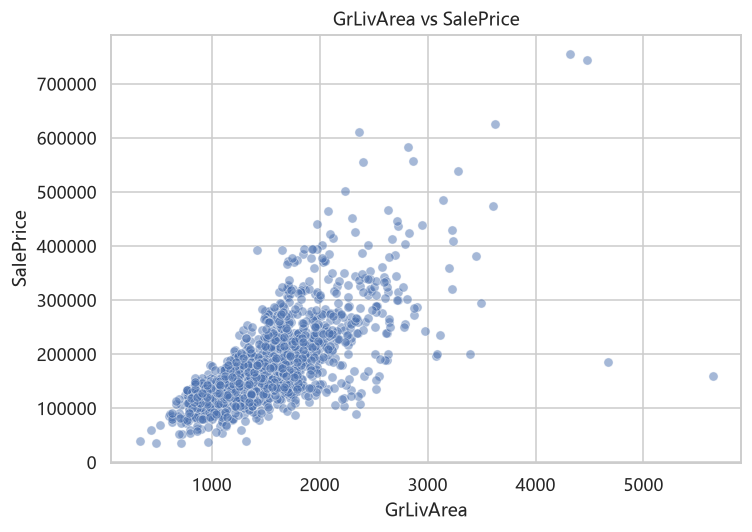

GrLivArea > 4500 的样本数: 2


,Id,GrLivArea,SalePrice,OverallQual
523,524,4676,184750,10
1298,1299,5642,160000,10


In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", alpha=0.5, ax=ax)
ax.set_title("GrLivArea vs SalePrice")
plt.tight_layout()
plt.show()

outliers = train[train["GrLivArea"] > 4500]
print(f"GrLivArea > 4500 的样本数: {len(outliers)}")
outliers[["Id", "GrLivArea", "SalePrice", "OverallQual"]]

## L4.3 · 类别 / 有序特征 vs 目标（前面漏掉的一块）

前面 `corr()` **只看了数值列**，43 个类别列完全没碰。但房价的很大一部分信号藏在类别里：

- **有序评级列**（`Ex > Gd > TA > Fa > Po`）：等级应当和价格**单调**对应
- **高基数类别**（`Neighborhood`）：不同小区的价格可能差 3 倍以上

**为什么用"中位数"而不是"均值"**：房价右偏，均值会被少数豪宅拉高；中位数更能代表"典型水平"。

> 💡 如果某等级显示 `NaN`，说明**训练集里没有这个等级的样本**（如 `KitchenQual` 没有 `Po`）。
> 这不代表要删掉该等级 —— 测试集里仍可能出现，编码时仍要给它留位置。

=== OverallQual（1~10）vs 房价中位数：应单调上升 ===
OverallQual
1      50150.0
2      60000.0
3      86250.0
4     108000.0
5     133000.0
6     160000.0
7     200141.0
8     269750.0
9     345000.0
10    432390.0
Name: SalePrice, dtype: float64

=== KitchenQual（有序评级）vs 房价中位数 ===
KitchenQual
Po         NaN
Fa    115000.0
TA    137000.0
Gd    201400.0
Ex    316750.0
Name: SalePrice, dtype: float64

=== Neighborhood：25 个小区，价格中位数跨度 ===
最便宜：MeadowV  88,000
最贵　：NridgHt  315,000
最贵 / 最便宜 = 3.6 倍


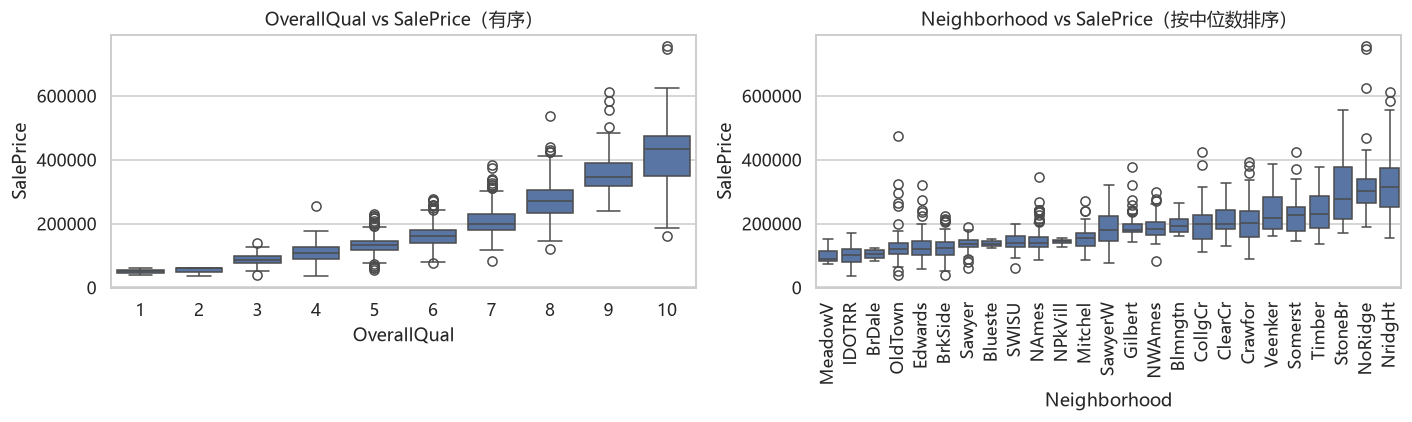

In [24]:
# ---- 1) 有序评级列：等级 vs 房价中位数（应当单调上升）----
ORDINAL = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
           "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
ORDER = ["Po", "Fa", "TA", "Gd", "Ex"]   # 从差到好

print("=== OverallQual（1~10）vs 房价中位数：应单调上升 ===")
print(train.groupby("OverallQual")["SalePrice"].median().round(0))

print("\n=== KitchenQual（有序评级）vs 房价中位数 ===")
print(train.groupby("KitchenQual")["SalePrice"].median().reindex(ORDER).round(0))

# ---- 2) 高基数类别：Neighborhood 价格跨度 ----
nb = (train.groupby("Neighborhood")["SalePrice"]
      .agg(median="median", count="count")
      .sort_values("median"))
print(f"\n=== Neighborhood：{len(nb)} 个小区，价格中位数跨度 ===")
print(f"最便宜：{nb.index[0]}  {nb['median'].iloc[0]:,.0f}")
print(f"最贵　：{nb.index[-1]}  {nb['median'].iloc[-1]:,.0f}")
print(f"最贵 / 最便宜 = {nb['median'].iloc[-1] / nb['median'].iloc[0]:.1f} 倍")

# ---- 3) 可视化：有序 + 高基数各看一个 ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=train, x="OverallQual", y="SalePrice", ax=axes[0])
axes[0].set_title("OverallQual vs SalePrice（有序）")
order_nb = nb.index.tolist()
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order_nb, ax=axes[1])
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_title("Neighborhood vs SalePrice（按中位数排序）")
plt.tight_layout()
plt.show()

## L5 · train/test 一致性检查

前四层都在看 `train`。但**真正决定 leaderboard 分数的，是 test 上的表现**。

这一步查 4 件事：

1. **列是否对齐** —— 少一列或多一列，都会让预测结果错位
2. **test 有没有 train 没见过的类别取值** —— 会让 One-Hot 编码掉列或直接报错
3. **test 的缺失值是否更严重** —— 有些列 train 不缺、test 却缺（很容易漏）
4. **数值分布是否漂移** —— 分布差太多，本地 CV 就不可信

> ⚠️ 这是**最容易漏、后果最严重**的一步。
> 前面统计缺失值只用了 `train`，这里要确认 `test` 是不是同样的情况。

只在 train 里的列: ['SalePrice']  <- 期望只有 ['SalePrice']
只在 test  里的列: []  <- 期望 []
特征列内容与顺序完全对齐 OK，共 79 列

只在 test 出现、train 未见过的取值: 无 ✓

=== test 缺失比 train 更严重的列（25 个）===
              train_missing  test_missing
PoolQC                 1453          1456
MiscFeature            1406          1408
MasVnrType              872           894
FireplaceQu             690           730
BsmtCond                 37            45
BsmtExposure             38            44
BsmtQual                 37            44
BsmtFinType1             37            42
BsmtFinType2             38            42
MasVnrArea                8            15
MSZoning                  0             4
Utilities                 0             2
Functional                0             2
BsmtFullBath              0             2
BsmtHalfBath              0             2
Exterior1st               0             1
Exterior2nd               0             1
BsmtUnfSF                 0             1
TotalBsmtSF               0         

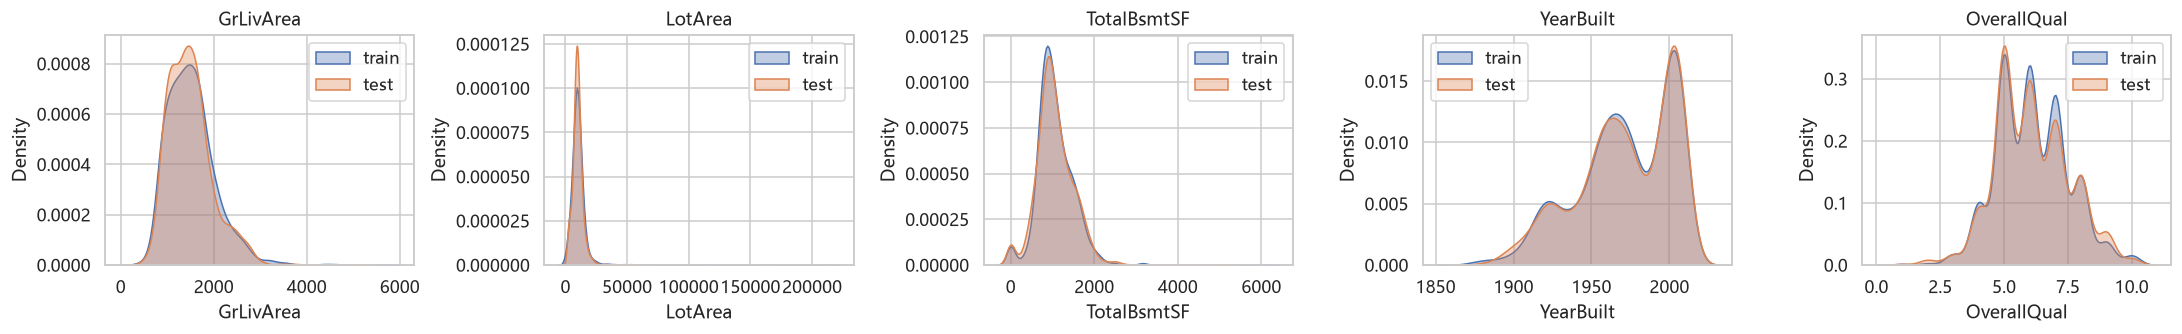

In [25]:
# 为什么要做这一步：如果 test 的分布和 train 不一致，或者 test 里有 train 没见过的
# 类别取值，那么本地 CV 再漂亮，提交上去也会崩。

# ---- 1) 列是否对齐 ----
only_train = sorted(set(train.columns) - set(test.columns))
only_test = sorted(set(test.columns) - set(train.columns))
print("只在 train 里的列:", only_train, " <- 期望只有 ['SalePrice']")
print("只在 test  里的列:", only_test, " <- 期望 []")

feat_cols = [c for c in train.columns if c not in ("Id", "SalePrice")]
test_feat_cols = [c for c in test.columns if c != "Id"]
if feat_cols == test_feat_cols:
    print(f"特征列内容与顺序完全对齐 OK，共 {len(feat_cols)} 列")
else:
    print("!! 特征列不一致，需要先对齐再往下做")
    print("   train 独有:", set(feat_cols) - set(test_feat_cols))
    print("   test  独有:", set(test_feat_cols) - set(feat_cols))

# ---- 2) 类别取值覆盖：只在 test 出现、train 没见过的取值 ----
# 这类取值会让 One-Hot 在 test 上多出一列（或直接 KeyError）
cat_feats = train[feat_cols].select_dtypes(exclude="number").columns
unseen = {}
for c in cat_feats:
    diff = set(test[c].dropna().unique()) - set(train[c].dropna().unique())
    if diff:
        unseen[c] = sorted(diff)
print("\n只在 test 出现、train 未见过的取值:", unseen if unseen else "无 ✓")

# ---- 3) 缺失值对比：test 有没有比 train 缺得更严重的列 ----
miss_cmp = pd.DataFrame({
    "train_missing": train[feat_cols].isna().sum(),
    "test_missing": test[feat_cols].isna().sum(),
})
miss_cmp = miss_cmp[miss_cmp.sum(axis=1) > 0]
worse = miss_cmp[miss_cmp.test_missing > miss_cmp.train_missing]
print(f"\n=== test 缺失比 train 更严重的列（{len(worse)} 个）===")
print(worse.sort_values("test_missing", ascending=False))

# ---- 4) 关键数值特征的分布是否漂移 ----
key_num = ["GrLivArea", "LotArea", "TotalBsmtSF", "YearBuilt", "OverallQual"]
fig, axes = plt.subplots(1, len(key_num), figsize=(4 * len(key_num), 3.2))
for ax, c in zip(axes, key_num):
    sns.kdeplot(train[c].dropna(), label="train", ax=ax, fill=True, alpha=.35)
    sns.kdeplot(test[c].dropna(), label="test", ax=ax, fill=True, alpha=.35)
    ax.set_title(c)
    ax.legend()
plt.tight_layout()
plt.show()

## L5.1 · 重复 / 分组检查（决定"该不该用分组切分"）

**做什么**：确认"每一行 = 一套**独立卖出**的房子"。

**为什么**：随机切分（`KFold`）隐含一个假设 —— **样本之间相互独立**。
如果同一个"实体"在数据里出现了多次（例如同一套房子被卖了两次），
随机切分就会把它**同时放进训练集和验证集**，造成**切分泄漏**、CV 分数虚高。
这时才需要用 `GroupKFold` 按"实体"分组切分。

> ⚠️ 别把两个概念搞混：
> - **分组聚合特征**（按 `Neighborhood` 算均价做 target encoding）→ **特征泄漏** → 用 OOF
> - **分组切分**（`GroupKFold`）→ **切分泄漏** → 只在"同一实体有多个样本"时需要
>
> 而 `Neighborhood`（小区）是**特征**，不是实体组 —— 同小区不同房子是**各自独立**的交易。

In [28]:
# ---- 1) Id 是否唯一（= 每行是一套独立房子）----
print("train Id 唯一?", train["Id"].is_unique, "| 行数", len(train), "| 唯一 Id", train["Id"].nunique())
print("test  Id 唯一?", test["Id"].is_unique)

# ---- 2) 有没有"特征完全相同"的房子（疑似同一套重复出售）----
feat = [c for c in train.columns if c not in ("Id", "SalePrice")]
dup = train.duplicated(subset=feat, keep=False)
print(f"\n特征完全相同的行数: {int(dup.sum())}（0 表示没有重复实体）")

# ---- 3) train / test 的 Id 是否有交集（真·泄漏）----
overlap = set(train["Id"]) & set(test["Id"])
print(f"train/test 的 Id 交集大小: {len(overlap)}（应为 0）")

# ---- 4) 参考：Neighborhood 只是"特征"，不是实体组 ----
print(f"\nNeighborhood 取值数: {train['Neighborhood'].nunique()}（每行仍是独立的一套房子）")

train Id 唯一? True | 行数 1460 | 唯一 Id 1460
test  Id 唯一? True

特征完全相同的行数: 0（0 表示没有重复实体）
train/test 的 Id 交集大小: 0（应为 0）

Neighborhood 取值数: 25（每行仍是独立的一套房子）


## 结论清单（EDA → 下一步动作）

EDA 的产出**不是图，而是一份可执行的清单**。填完下面这张表，就可以进特征工程了：

| 发现 | 下一步动作 |
|------|-----------|
| `SalePrice` 偏度 1.88（右偏）；`log1p` 后 0.12 | 对目标做 `log1p`，CV 用 RMSE-log |
| **共 19 列有缺失 = 17 列语义缺失 + 2 列真缺失** | 15 个分类列填 `"None"`；`GarageYrBlt`/`MasVnrArea` 填 `0`；`LotFrontage`/`Electrical` 用统计量 |
| ⚠️ `MasVnrType` 是**混合缺失**：859 无饰面 / 5 真缺失 / 8 两列同缺 | 不能一刀切；那 5 行（`MasVnrArea>0`）应单独填补类型 |
| 真缺失只有 `LotFrontage`(259) 和 `Electrical`(1) | `LotFrontage` 按 `Neighborhood` 分组取中位数；`Electrical` 取众数 |
| **⚠️ test 有 15 列缺失，但 train 完全不缺**（`MSZoning`/`KitchenQual`/`GarageCars`/`BsmtFullBath`…） | 这些列**必须**在 `Pipeline` 里统一填充；否则预测时 `NaN` 会让模型直接报错 |
| 部分数值列偏度 > 1（`LotArea` 12.2、`MiscVal` 24.5、`PoolArea` 14.8） | 一般用 log / Box-Cox；但 `MiscVal`/`PoolArea` 是稀疏 0，改做 0-1 标志（`HasPool` 等） |
| 类别列基数差异大（`Neighborhood` 25 ~ 2） | 低基数 One-Hot；`Neighborhood` 可考虑 target encoding |
| **"假数值"两类**：① 名义 → `MSSubClass`(15)；② 有序/时间 → `OverallQual`(10)、`OverallCond`(9)、`MoSold`(12)、`YrSold`(5) | 名义列当**类别**；有序列当**序数**；都不能当连续数值 |
| **有序评级列**（10 列，`Ex>Gd>TA>Fa>Po`） | 转成 0~4 序数编码（例：`KitchenQual` 中位数 Fa=11.5 万 → TA=13.7 万 → Gd=20.1 万 → Ex=31.7 万，单调；`Po` 在本数据无样本） |
| `OverallQual`(0.79) / `GrLivArea`(0.71) 相关性最高 | 优先保留，并构造交互特征（如 `OverallQual × GrLivArea`） |
| `Neighborhood` 价格中位数跨 8.8 万(`MeadowV`) ~ 31.5 万(`NridgHt`)，**约 3.6 倍** | 强类别特征，必须保留 |
| `GrLivArea` 离群：`Id=524/1299`（面积 >4500 但价格很低）；IQR 上界 2748 外共 31 个 | **先别删**，标记出来，建模阶段用 CV 验证是否该剔除 |
| L5：train/test 列已对齐；**test 无 train 未见过的类别取值** | One-Hot 仍建议 `handle_unknown="ignore"` 兜底 |

> ⚠️ **数据泄漏红线**：上面所有"填什么值"的决定，如果在**全量数据**上算统计量
> （比如用全体中位数填 `LotFrontage`），CV 分数会虚高、LB 会打脸。
> 正确做法是把编码 / 填充都放进 `sklearn.Pipeline`，**在每一折的训练集内拟合**。